# UMAP KNN Label Transfer — with Distance & Probability Scores

Runs supervised UMAP + KNN label transfer for **EXC** and **INH** cells,
then inspects the new `knn_stats` DataFrame and saves results to h5ad.

Columns produced per minnie cell:

| Column | Description |
|--------|-------------|
| `predicted_label` | majority-vote winner |
| `predicted_probability` | vote_count / k |
| `predicted_avg_distance` | mean UMAP distance to winning-label neighbors |
| `runner_up_1_label` | 2nd-ranked label |
| `runner_up_1_probability` | vote_count / k for runner-up 1 |
| `runner_up_1_avg_distance` | mean distance to runner-up 1 neighbors |
| `runner_up_2_label` | 3rd-ranked label |
| `runner_up_2_probability` | vote_count / k for runner-up 2 |
| `runner_up_2_avg_distance` | mean distance to runner-up 2 neighbors |

Ties in vote count are broken by ascending average distance (closer = better rank).

In [1]:
import sys
import os

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

%load_ext autoreload
%autoreload 2

from umap_label_transfer import UMAPLabelTransfer
import anndata as ad
import pandas as pd

DATA_ROOT = '/scratch/combined_datasets'
H5AD_OUT  = '/scratch/h5ad_outputs'

## EXC — supervised UMAP + KNN

Patchseq features: (389, 53)
Unique patchseq cells: 384, unique labels: 17 (deepest label only)
Patchseq after label join: (384, 56)
Minnie features: (49714, 58)
Shared features:  48
Only in patchseq: 4  → ['axon_exit_theta', 'heirachy_category', 'level', 'axon_exit_distance']
Only in minnie:   7  → ['basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_5', 'basal_dendrite_depth_pc_2', 'soma_surface_area', 'basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_4']
Patchseq: 384 → 384 rows (dropped 0)
Minnie:   49714 → 49714 rows (dropped 0)
Scaled patchseq (robust): (384, 48)
Scaled minnie   (robust): (49714, 48)
Patchseq embedding (supervised): (384, 2)
Minnie embedding   (supervised): (49714, 2)
Minnie predicted label counts:
  L5 IT-2                                            20760
  L4 IT                                              10721
  L6 IT-2                                            6567
  L6b                                                2137


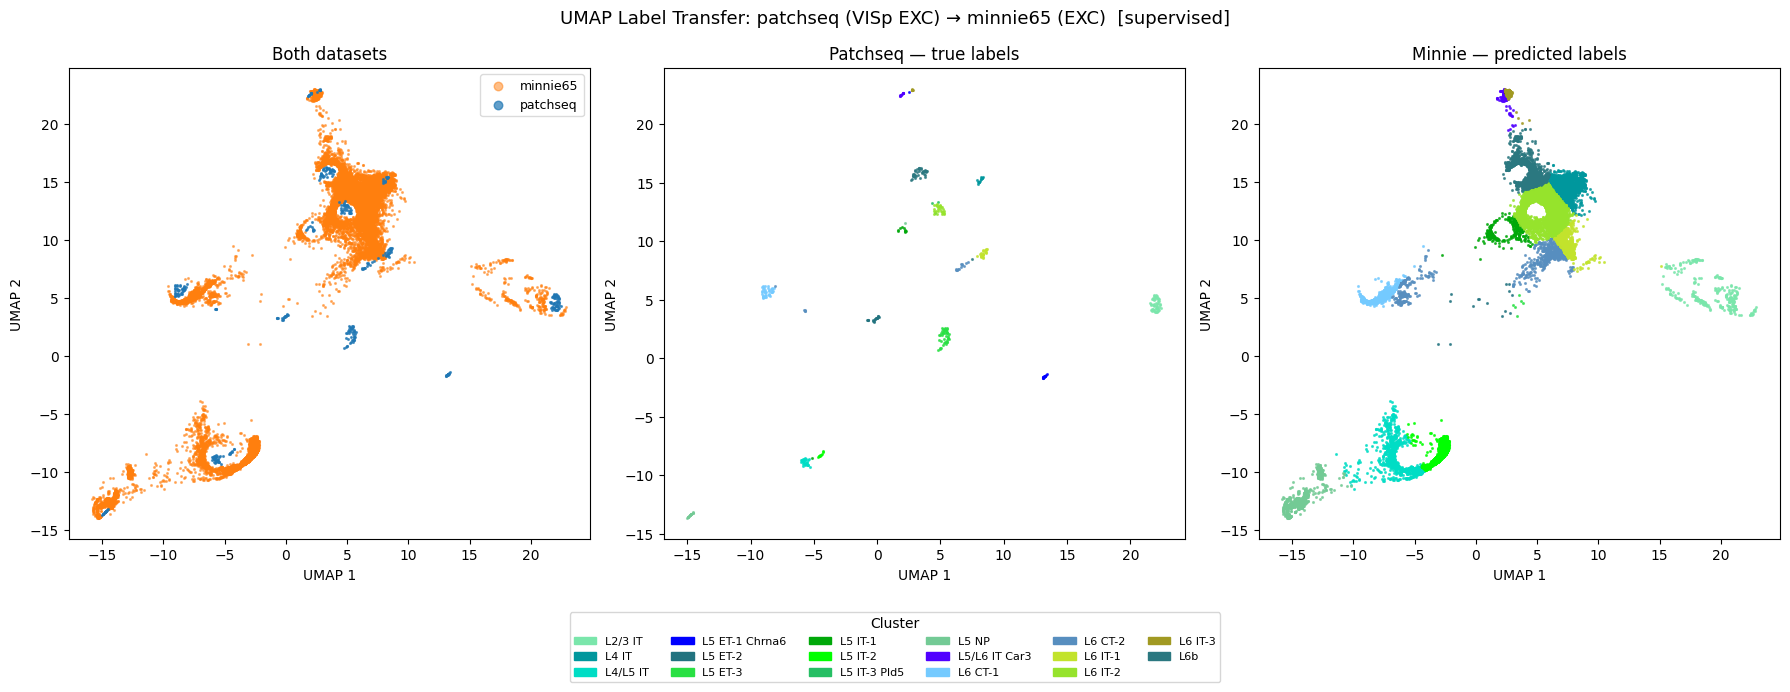

In [2]:
lt_exc = UMAPLabelTransfer(DATA_ROOT, cell_type='exc')
lt_exc.load_data()
lt_exc.harmonize_features()
lt_exc.scale(method='robust')
lt_exc.fit_umap(mode='supervised')
lt_exc.transfer_labels(k=5)
lt_exc.plot_umap()

In [3]:
print('EXC knn_stats shape:', lt_exc.knn_stats.shape)
lt_exc.knn_stats.head(10)

EXC knn_stats shape: (49714, 10)


,id,predicted_label,predicted_probability,predicted_avg_distance,runner_up_1_label,runner_up_1_probability,runner_up_1_avg_distance,runner_up_2_label,runner_up_2_probability,runner_up_2_avg_distance
0,23141,L6b,1.0,1.137475,None,NaN,NaN,None,NaN,NaN
1,23332,L6 IT-1,0.8,0.831320,L6b,0.2,0.690846,None,NaN,NaN
2,23373,L5 IT-2,1.0,1.560962,None,NaN,NaN,None,NaN,NaN
3,23382,L6 IT-1,0.8,0.753741,L6b,0.2,0.817720,None,NaN,NaN
4,23385,L5 IT-2,1.0,1.461509,None,NaN,NaN,None,NaN,NaN
5,23388,L6 IT-2,1.0,1.029415,None,NaN,NaN,None,NaN,NaN
6,23389,L4 IT,1.0,0.700044,None,NaN,NaN,None,NaN,NaN
7,23398,L4 IT,1.0,0.721125,None,NaN,NaN,None,NaN,NaN
8,23413,L5 IT-2,1.0,1.725958,None,NaN,NaN,None,NaN,NaN
9,23550,L4 IT,1.0,0.650270,None,NaN,NaN,None,NaN,NaN


In [4]:
exc_path = os.path.join(H5AD_OUT, 'exc_minnie_met_umapknn_wScores.h5ad')
lt_exc.save_knn_labels_h5ad(exc_path)

Saved knn_stats h5ad → /scratch/h5ad_outputs/exc_minnie_met_umapknn_wScores.h5ad  (49714 cells)


## INH — supervised UMAP + KNN

Patchseq features: (520, 49)
Unique patchseq cells: 495, unique labels: 28 (deepest label only)
Patchseq after label join: (495, 52)
Minnie features: (163, 54)
Shared features:  46
Only in patchseq: 2  → ['heirachy_category', 'level']
Only in minnie:   5  → ['basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_2', 'basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_4']
Patchseq: 495 → 495 rows (dropped 0)
Minnie:   163 → 163 rows (dropped 0)
Scaled patchseq (robust): (495, 46)
Scaled minnie   (robust): (163, 46)
Patchseq embedding (supervised): (495, 2)
Minnie embedding   (supervised): (163, 2)
Minnie predicted label counts:
  Vip-MET-5                                          55
  Sst-MET-9                                          32
  Vip-MET-1                                          19
  Sncg-MET-1                                         12
  Pvalb-MET-4                                        10
  Sst-MET-2                                          6


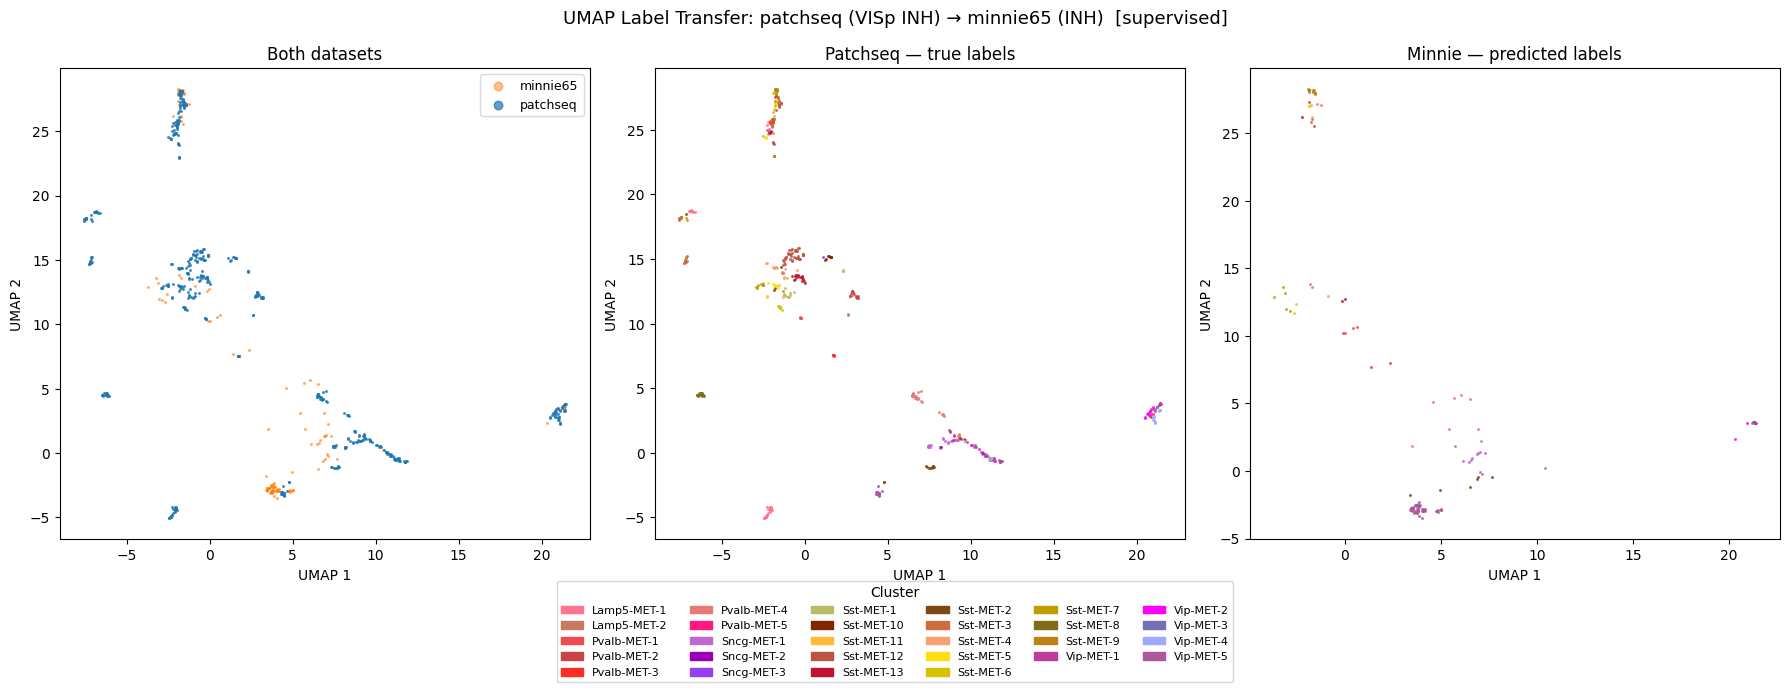

In [5]:
lt_inh = UMAPLabelTransfer(DATA_ROOT, cell_type='inh')
lt_inh.load_data()
lt_inh.harmonize_features()
lt_inh.scale(method='robust')
lt_inh.fit_umap(mode='supervised')
lt_inh.transfer_labels(k=5)
lt_inh.plot_umap()

In [6]:
print('INH knn_stats shape:', lt_inh.knn_stats.shape)
lt_inh.knn_stats.head(10)

INH knn_stats shape: (163, 10)


,id,predicted_label,predicted_probability,predicted_avg_distance,runner_up_1_label,runner_up_1_probability,runner_up_1_avg_distance,runner_up_2_label,runner_up_2_probability,runner_up_2_avg_distance
0,252232,Sst-MET-9,1.0,0.145963,None,NaN,NaN,None,NaN,NaN
1,255120,Vip-MET-5,0.8,0.556023,Sst-MET-2,0.2,0.640061,None,NaN,NaN
2,255129,Sst-MET-11,0.4,0.571345,Sst-MET-7,0.4,1.121178,Sst-MET-6,0.2,1.138083
3,255137,Vip-MET-5,1.0,0.875754,None,NaN,NaN,None,NaN,NaN
4,255208,Vip-MET-5,1.0,0.670438,None,NaN,NaN,None,NaN,NaN
5,255218,Sst-MET-9,1.0,0.145768,None,NaN,NaN,None,NaN,NaN
6,256424,Vip-MET-5,1.0,0.660852,None,NaN,NaN,None,NaN,NaN
7,256426,Vip-MET-1,0.6,0.138265,Pvalb-MET-5,0.2,0.061309,Vip-MET-3,0.2,0.117908
8,256446,Vip-MET-5,0.8,0.648093,Sncg-MET-3,0.2,0.598850,None,NaN,NaN
9,256514,Vip-MET-5,1.0,0.843458,None,NaN,NaN,None,NaN,NaN


In [7]:
inh_path = os.path.join(H5AD_OUT, 'inh_minnie_met_umapknn_wScores.h5ad')
lt_inh.save_knn_labels_h5ad(inh_path)

Saved knn_stats h5ad → /scratch/h5ad_outputs/inh_minnie_met_umapknn_wScores.h5ad  (163 cells)


## Read back and verify

In [8]:
for label, path in [('EXC', exc_path), ('INH', inh_path)]:
    adata = ad.read_h5ad(path)
    print(f'--- {label} ({adata.n_obs} cells) ---')
    display(adata.obs.head(5))
    print()

--- EXC (49714 cells) ---


,id,predicted_label,predicted_probability,predicted_avg_distance,runner_up_1_label,runner_up_1_probability,runner_up_1_avg_distance,runner_up_2_label,runner_up_2_probability,runner_up_2_avg_distance
0,23141,L6b,1.0,1.137475,NaN,NaN,NaN,NaN,NaN,NaN
1,23332,L6 IT-1,0.8,0.831320,L6b,0.2,0.690846,NaN,NaN,NaN
2,23373,L5 IT-2,1.0,1.560962,NaN,NaN,NaN,NaN,NaN,NaN
3,23382,L6 IT-1,0.8,0.753741,L6b,0.2,0.817720,NaN,NaN,NaN
4,23385,L5 IT-2,1.0,1.461509,NaN,NaN,NaN,NaN,NaN,NaN



--- INH (163 cells) ---


,id,predicted_label,predicted_probability,predicted_avg_distance,runner_up_1_label,runner_up_1_probability,runner_up_1_avg_distance,runner_up_2_label,runner_up_2_probability,runner_up_2_avg_distance
0,252232,Sst-MET-9,1.0,0.145963,NaN,NaN,NaN,NaN,NaN,NaN
1,255120,Vip-MET-5,0.8,0.556023,Sst-MET-2,0.2,0.640061,NaN,NaN,NaN
2,255129,Sst-MET-11,0.4,0.571345,Sst-MET-7,0.4,1.121178,Sst-MET-6,0.2,1.138083
3,255137,Vip-MET-5,1.0,0.875754,NaN,NaN,NaN,NaN,NaN,NaN
4,255208,Vip-MET-5,1.0,0.670438,NaN,NaN,NaN,NaN,NaN,NaN
